# Pre-processing
- One-hot encode categorical variables.
- Train/test split your data.
- Scale your data.
- Consider using automated feature selection.

# Modeling
- **Establish your baseline score.**
- Fit linear regression. Look at your coefficients. Are any of them wildly overblown?
- Fit lasso/ridge/elastic net with default parameters.
- Go back and remove features that might be causing issues in your models.
- Tune hyperparameters.
- **Identify a production model.** (This does not have to be your best performing Kaggle model, but rather the model that best answers your problem statement.)
- Refine and interpret your production model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, Lasso, Ridge 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

In [2]:
df_train = pd.read_csv('./data/train_cleaned.csv')
df_test = pd.read_csv('./data/test_cleaned.csv')

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850 entries, 0 to 1849
Data columns (total 83 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1850 non-null   int64  
 1   pid                    1850 non-null   int64  
 2   ms_subclass            1850 non-null   int64  
 3   ms_zoning              1850 non-null   object 
 4   lot_frontage           1850 non-null   float64
 5   lot_area               1850 non-null   int64  
 6   street                 1850 non-null   object 
 7   alley                  1850 non-null   object 
 8   lot_shape              1850 non-null   object 
 9   land_contour           1850 non-null   object 
 10  utilities              1850 non-null   object 
 11  lot_config             1850 non-null   object 
 12  land_slope             1850 non-null   object 
 13  neighborhood           1850 non-null   object 
 14  condition_1            1850 non-null   object 
 15  cond

In [4]:
df_train = df_train.drop(['pid'], axis=1)

In [5]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878 entries, 0 to 877
Data columns (total 82 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     878 non-null    int64  
 1   pid                    878 non-null    int64  
 2   ms_subclass            878 non-null    int64  
 3   ms_zoning              878 non-null    object 
 4   lot_frontage           718 non-null    float64
 5   lot_area               878 non-null    int64  
 6   street                 878 non-null    object 
 7   alley                  58 non-null     object 
 8   lot_shape              878 non-null    object 
 9   land_contour           878 non-null    object 
 10  utilities              878 non-null    object 
 11  lot_config             878 non-null    object 
 12  land_slope             878 non-null    object 
 13  neighborhood           878 non-null    object 
 14  condition_1            878 non-null    object 
 15  condit

In [6]:
df_train.dropna(subset=['garage_area'], inplace=True)
df_train['garage_area'].isna().sum()

0

In [7]:
garage_features = df_train[['garage_type', 'garage_finish', 'garage_qual', 'has_garage', 'garage_during_remodel']]
train_encoded = pd.get_dummies(data=garage_features)
X = pd.concat([train_encoded, df_train[['garage_area', 'garage_cars']]], axis=1)
y = df_train['saleprice']

In [8]:
#split training data into training and validation set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

# Instantiate and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
# Evaluate the model
train_score = model.score(X_train, y_train)
val_score = model.score(X_val, y_val)

print(f'Train Score: {train_score}')
print(f'Val Score: {val_score}')

Train Score: 0.5975947971430908
Val Score: 0.5906867820285278


In [10]:
# Get the coefficients of the features
coefficients = pd.Series(model.coef_, index=X_train.columns)
sorted_coefficients = coefficients.abs().sort_values(ascending=False)
print(sorted_coefficients)

garage_type_BuiltIn      51432.949236
garage_type_2Types       46487.675720
garage_type_CarPort      37534.976208
garage_qual_Gd           37441.264811
garage_qual_Ex           36127.209474
garage_type_Attchd       33436.046777
garage_cars              22964.654168
garage_finish_Unf        22204.933474
garage_qual_Po           20639.032721
garage_finish_Fin        15065.963259
garage_type_None         13468.619798
garage_qual_None         13468.619798
garage_finish_None       13468.619798
has_garage               13468.619798
garage_type_Basment      12238.343658
garage_during_remodel    10627.688192
garage_finish_RFn         6329.649582
garage_qual_TA            4609.744263
garage_type_Detchd        2076.620224
garage_qual_Fa            1246.613323
garage_area                149.877535
dtype: float64


In [11]:
# Predict on validation set
y_pred_val = model.predict(X_val)

# R-squared
r2 = r2_score(y_val, y_pred_val)

# MSE and RMSE
mse = mean_squared_error(y_val, y_pred_val)
rmse = np.sqrt(mse)

# MAE
mae = mean_absolute_error(y_val, y_pred_val)

print(f'R-squared: {r2:.4f}')
print(f'Mean Squared Error: {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')


R-squared: 0.5907
Mean Squared Error: 2322412179.46
Root Mean Squared Error: 48191.41
Mean Absolute Error: 34261.90


In [12]:
garage_features = df_train[['ms_zoning','garage_type', 'garage_finish', 'garage_qual', 'has_garage', 'garage_during_remodel']]
train_encoded = pd.get_dummies(data=garage_features)
X = pd.concat([train_encoded, df_train[['garage_area', 'garage_cars']]], axis=1)
y = df_train['saleprice']

In [13]:
#split training data into training and validation set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

# Instantiate and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
# Evaluate the model
train_score = model.score(X_train, y_train)
val_score = model.score(X_val, y_val)

print(f'Train Score: {train_score}')
print(f'Val Score: {val_score}')

Train Score: 0.6045083619397955
Val Score: 0.6005850900279909


In [15]:
# Lasso
lasso = Lasso()
lasso.fit(X_train, y_train)
lasso_train_score = lasso.score(X_train, y_train)
lasso_val_score = lasso.score(X_val, y_val)

print(f'Lasso Train Score: {lasso_train_score}')
print(f'Lasso Val Score: {lasso_val_score}')

Lasso Train Score: 0.6045075716249151
Lasso Val Score: 0.6005565068056169


In [16]:
# Ridge
ridge = Ridge()
ridge.fit(X_train, y_train)
ridge_train_score = ridge.score(X_train, y_train)
ridge_val_score = ridge.score(X_val, y_val)

print(f'Ridge Train Score: {ridge_train_score}')
print(f'Ridge Val Score: {ridge_val_score}')

Ridge Train Score: 0.603740702972857
Ridge Val Score: 0.6000301299347556


In [17]:
# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the StandardScaler to the training data
scaler.fit(X_train)

# Transform the training and validation data
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [18]:
# LassoCV
lasso_cv = LassoCV(alphas=np.logspace(-3, 3, 7))
lasso_cv.fit(X_train_scaled, y_train)
print(f'Optimal Lasso Alpha: {lasso_cv.alpha_}')
print(f'LassoCV Train Score: {lasso_cv.score(X_train_scaled, y_train)}')
print(f'LassoCV Val Score: {lasso_cv.score(X_val_scaled, y_val)}')

# RidgeCV
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 7))
ridge_cv.fit(X_train_scaled, y_train)
print(f'Optimal Ridge Alpha: {ridge_cv.alpha_}')
print(f'RidgeCV Train Score: {ridge_cv.score(X_train_scaled, y_train)}')
print(f'RidgeCV Val Score: {ridge_cv.score(X_val_scaled, y_val)}')


Optimal Lasso Alpha: 1000.0
LassoCV Train Score: 0.6014977795346799
LassoCV Val Score: 0.5966520872652115
Optimal Ridge Alpha: 100.0
RidgeCV Train Score: 0.6031324991965977
RidgeCV Val Score: 0.6010355344136089


In [19]:
# Define a list of parameters for Lasso
params_lasso = {'alpha': np.logspace(-4, 4, 20), 'max_iter': [1000, 5000, 10000]}

# Use grid search to find the optimal parameters
grid_lasso = GridSearchCV(Lasso(), params_lasso, cv=5, scoring='r2')

# Fit the grid search object to the data
grid_lasso.fit(X_train, y_train)

# Print the best parameters and the best score
print(f'Best Lasso Parameters: {grid_lasso.best_params_}')
print(f'Best Lasso Score: {grid_lasso.best_score_}')

Best Lasso Parameters: {'alpha': 78.47599703514607, 'max_iter': 1000}
Best Lasso Score: 0.5849259564692983


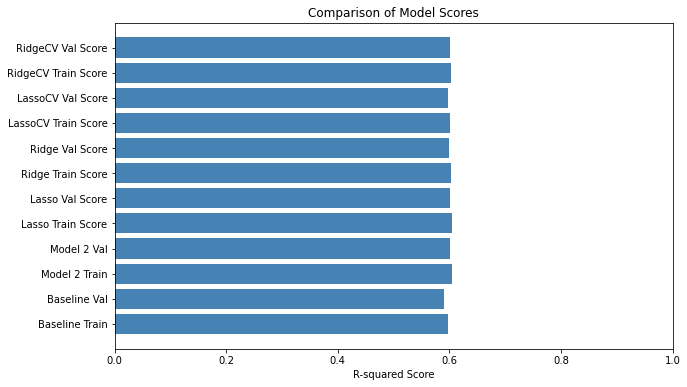

In [40]:
# Define a dictionary with model names as keys and their scores as values
scores = {
    'Baseline Train': 0.5975947971430908,
    'Baseline Val': 0.5906867820285278,
    'Model 2 Train': 0.6045083619397955,
    'Model 2 Val': 0.6005850900279909,
    'Lasso Train Score': 0.6045075716249151,
    'Lasso Val Score': 0.6005565068056169,
    'Ridge Train Score': 0.603740702972857,
    'Ridge Val Score': 0.6000301299347556,
    'LassoCV Train Score': 0.6014977795346799,
    'LassoCV Val Score': 0.5966520872652115,
    'RidgeCV Train Score': 0.6031324991965977,
    'RidgeCV Val Score': 0.6010355344136089,
}

# Create lists of model names and their corresponding scores
models = list(scores.keys())
score_values = list(scores.values())

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.barh(models, score_values, color='steelblue')
plt.xlabel('R-squared Score')
plt.title('Comparison of Model Scores')
plt.xlim([0, 1])  # This line is optional, it just sets the x-axis limits to be between 0 and 1
plt.show()


In [20]:
garage_features_test = df_test[['ms_zoning','garage_type', 'garage_finish', 'garage_qual', 'has_garage', 'garage_during_remodel']]
test_encoded = pd.get_dummies(data=garage_features_test)
X_test = pd.concat([test_encoded, df_test[['garage_area', 'garage_cars']]], axis=1)

In [22]:
 # Ensure the order of column in the test set is in the same order as in train set
X_test = X_test[X_train.columns]

In [23]:
preds = grid_lasso.predict(X_test)

In [24]:
preds.shape

(878,)

In [26]:
df_test['SalePrice'] = preds

In [32]:
submission = df_test[['id','SalePrice']]

In [33]:
submission = submission.rename(columns={'id': 'Id'})

In [35]:
submission.to_csv('submission.csv', index=False)
submission

,Id,SalePrice
0,2658,115216.055709
1,2718,225891.445329
2,2414,182136.075713
3,1989,143398.444604
4,625,195175.841474
...,...,...
873,1662,175174.088946
874,1234,201361.608328
875,1373,128321.126349
876,1672,158881.584505


In [36]:
df_test.to_csv('./data/predictions.csv', index = False)